In [45]:
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns

In [46]:
FX = pd.read_csv("data/raw/011111.txt")
print(FX.head())

  <TICKER>  <DTYYYYMMDD>  <TIME>  <OPEN>  <HIGH>   <LOW>  <CLOSE>
0   EURUSD      20111101     100  1.3841  1.3842  1.3841   1.3841
1   EURUSD      20111101     200  1.3841  1.3841  1.3840   1.3840
2   EURUSD      20111101     300  1.3841  1.3841  1.3835   1.3836
3   EURUSD      20111101     400  1.3836  1.3836  1.3836   1.3836
4   EURUSD      20111101     500  1.3837  1.3837  1.3833   1.3835


In [47]:
names = []
for name in FX.columns:
    names.append(re.sub(r"^<(.*)>$", r"\1", name))
FX.columns = names
print(FX.head())

   TICKER  DTYYYYMMDD  TIME    OPEN    HIGH     LOW   CLOSE
0  EURUSD    20111101   100  1.3841  1.3842  1.3841  1.3841
1  EURUSD    20111101   200  1.3841  1.3841  1.3840  1.3840
2  EURUSD    20111101   300  1.3841  1.3841  1.3835  1.3836
3  EURUSD    20111101   400  1.3836  1.3836  1.3836  1.3836
4  EURUSD    20111101   500  1.3837  1.3837  1.3833  1.3835


In [48]:
for i in range(len(FX["TICKER"])):
    FX.loc[i, "TICKER"] = re.sub(r"^(\w{3})(\w{3})$", r"\1/\2", FX.loc[i, "TICKER"] )
print(FX.head())

    TICKER  DTYYYYMMDD  TIME    OPEN    HIGH     LOW   CLOSE
0  EUR/USD    20111101   100  1.3841  1.3842  1.3841  1.3841
1  EUR/USD    20111101   200  1.3841  1.3841  1.3840  1.3840
2  EUR/USD    20111101   300  1.3841  1.3841  1.3835  1.3836
3  EUR/USD    20111101   400  1.3836  1.3836  1.3836  1.3836
4  EUR/USD    20111101   500  1.3837  1.3837  1.3833  1.3835


In [49]:
for i in range(len(FX["TIME"])):
    time_i = str(FX.loc[i, "TIME"]).zfill(6)
    FX.loc[i, "TIME"] = re.sub(r"(\d{2})(\d{2})(\d{2})$", r"\1:\2:\3", time_i)
print(FX.head())

C:\Users\raphe\AppData\Local\Temp\ipykernel_38308\1393786362.py:3: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '00:01:00' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  FX.loc[i, "TIME"] = re.sub(r"(\d{2})(\d{2})(\d{2})$", r"\1:\2:\3", time_i)


    TICKER  DTYYYYMMDD      TIME    OPEN    HIGH     LOW   CLOSE
0  EUR/USD    20111101  00:01:00  1.3841  1.3842  1.3841  1.3841
1  EUR/USD    20111101  00:02:00  1.3841  1.3841  1.3840  1.3840
2  EUR/USD    20111101  00:03:00  1.3841  1.3841  1.3835  1.3836
3  EUR/USD    20111101  00:04:00  1.3836  1.3836  1.3836  1.3836
4  EUR/USD    20111101  00:05:00  1.3837  1.3837  1.3833  1.3835


In [50]:
for i in range(len(FX["DTYYYYMMDD"])):
    FX.loc[i, "DTYYYYMMDD"] = re.sub(r"(\d{4})(\d{2})(\d{2})$", r"\1-\2-\3", str(FX.loc[i, "DTYYYYMMDD"]))
print(FX.head())

C:\Users\raphe\AppData\Local\Temp\ipykernel_38308\180701017.py:2: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '2011-11-01' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  FX.loc[i, "DTYYYYMMDD"] = re.sub(r"(\d{4})(\d{2})(\d{2})$", r"\1-\2-\3", str(FX.loc[i, "DTYYYYMMDD"]))


    TICKER  DTYYYYMMDD      TIME    OPEN    HIGH     LOW   CLOSE
0  EUR/USD  2011-11-01  00:01:00  1.3841  1.3842  1.3841  1.3841
1  EUR/USD  2011-11-01  00:02:00  1.3841  1.3841  1.3840  1.3840
2  EUR/USD  2011-11-01  00:03:00  1.3841  1.3841  1.3835  1.3836
3  EUR/USD  2011-11-01  00:04:00  1.3836  1.3836  1.3836  1.3836
4  EUR/USD  2011-11-01  00:05:00  1.3837  1.3837  1.3833  1.3835


In [51]:
FX["DATETIME"] = FX["DTYYYYMMDD"].astype(str) + " " + FX["TIME"].astype(str)
FX["DATETIME"] = pd.to_datetime(FX["DATETIME"], format="%Y-%m-%d %H:%M:%S")
FX = FX.set_index("DATETIME")
print(FX.head())

                      TICKER  DTYYYYMMDD      TIME    OPEN    HIGH     LOW  \
DATETIME                                                                     
2011-11-01 00:01:00  EUR/USD  2011-11-01  00:01:00  1.3841  1.3842  1.3841   
2011-11-01 00:02:00  EUR/USD  2011-11-01  00:02:00  1.3841  1.3841  1.3840   
2011-11-01 00:03:00  EUR/USD  2011-11-01  00:03:00  1.3841  1.3841  1.3835   
2011-11-01 00:04:00  EUR/USD  2011-11-01  00:04:00  1.3836  1.3836  1.3836   
2011-11-01 00:05:00  EUR/USD  2011-11-01  00:05:00  1.3837  1.3837  1.3833   

                      CLOSE  
DATETIME                     
2011-11-01 00:01:00  1.3841  
2011-11-01 00:02:00  1.3840  
2011-11-01 00:03:00  1.3836  
2011-11-01 00:04:00  1.3836  
2011-11-01 00:05:00  1.3835  


In [52]:
FX.to_csv("data/clean/FX.csv")

In [53]:
curr_nb = FX.groupby("TICKER").size()
print(curr_nb.head())

TICKER
AUD/CAD    1440
AUD/CHF    1440
AUD/JPY    1438
AUD/NZD    1440
AUD/USD    1440
dtype: int64


In [54]:
first_open = FX.groupby("TICKER")["OPEN"].first()
print(first_open.head())

TICKER
AUD/CAD     1.0532
AUD/CHF     0.9250
AUD/JPY    82.4500
AUD/NZD     1.3051
AUD/USD     1.0536
Name: OPEN, dtype: float64


In [55]:
normalized_FX = FX.groupby("TICKER", group_keys=False).apply(
    lambda g: g.assign(
        OPEN=g["OPEN"] / g["OPEN"].iloc[0],
        HIGH=g["HIGH"] / g["OPEN"].iloc[0],
        LOW=g["LOW"] / g["OPEN"].iloc[0],
        CLOSE=g["CLOSE"] / g["OPEN"].iloc[0]
    )
)
print(normalized_FX.head())

                      TICKER  DTYYYYMMDD      TIME  OPEN      HIGH       LOW  \
DATETIME                                                                       
2011-11-01 00:01:00  AUD/CAD  2011-11-01  00:01:00   1.0  1.000095  1.000000   
2011-11-01 00:01:00  AUD/CHF  2011-11-01  00:01:00   1.0  1.000000  0.999892   
2011-11-01 00:01:00  AUD/JPY  2011-11-01  00:01:00   1.0  1.000364  0.999879   
2011-11-01 00:01:00  AUD/NZD  2011-11-01  00:01:00   1.0  1.000000  0.999770   
2011-11-01 00:01:00  AUD/USD  2011-11-01  00:01:00   1.0  1.000095  1.000000   

                        CLOSE  
DATETIME                       
2011-11-01 00:01:00  1.000095  
2011-11-01 00:01:00  1.000000  
2011-11-01 00:01:00  1.000364  
2011-11-01 00:01:00  0.999770  
2011-11-01 00:01:00  1.000095  


C:\Users\raphe\AppData\Local\Temp\ipykernel_38308\3571653881.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  normalized_FX = FX.groupby("TICKER", group_keys=False).apply(


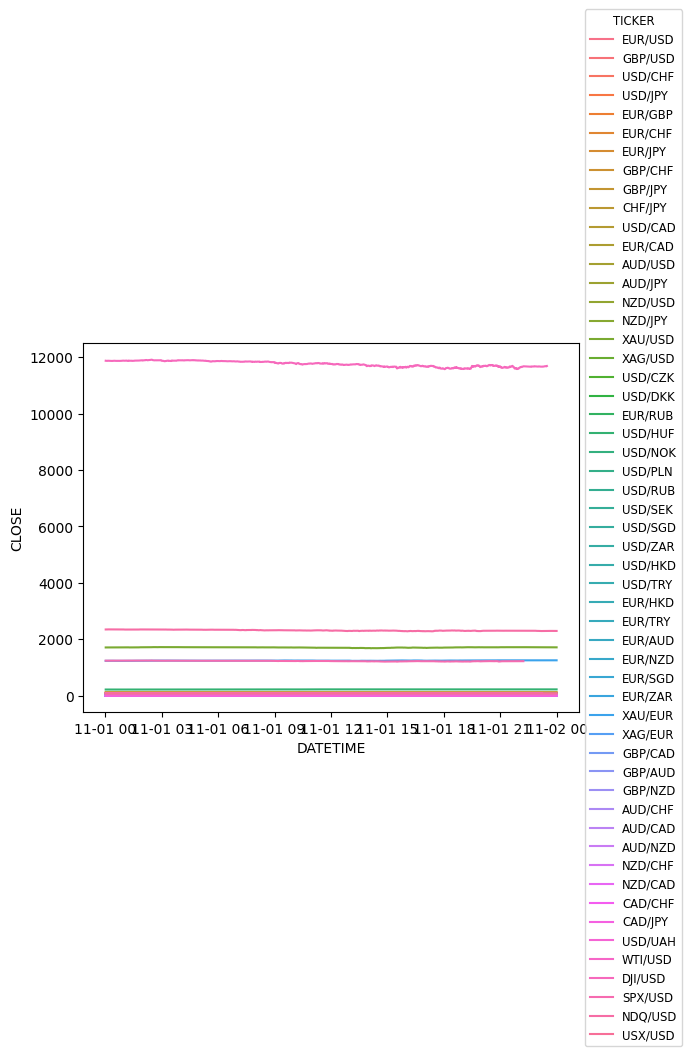

In [58]:
sns.lineplot(x="DATETIME", y="CLOSE", hue = "TICKER", data=FX)
plt.legend(
    title="TICKER",
    fontsize="small",
    title_fontsize="small",
    loc="center left",
    bbox_to_anchor=(1, 0.5)
)
plt.show()

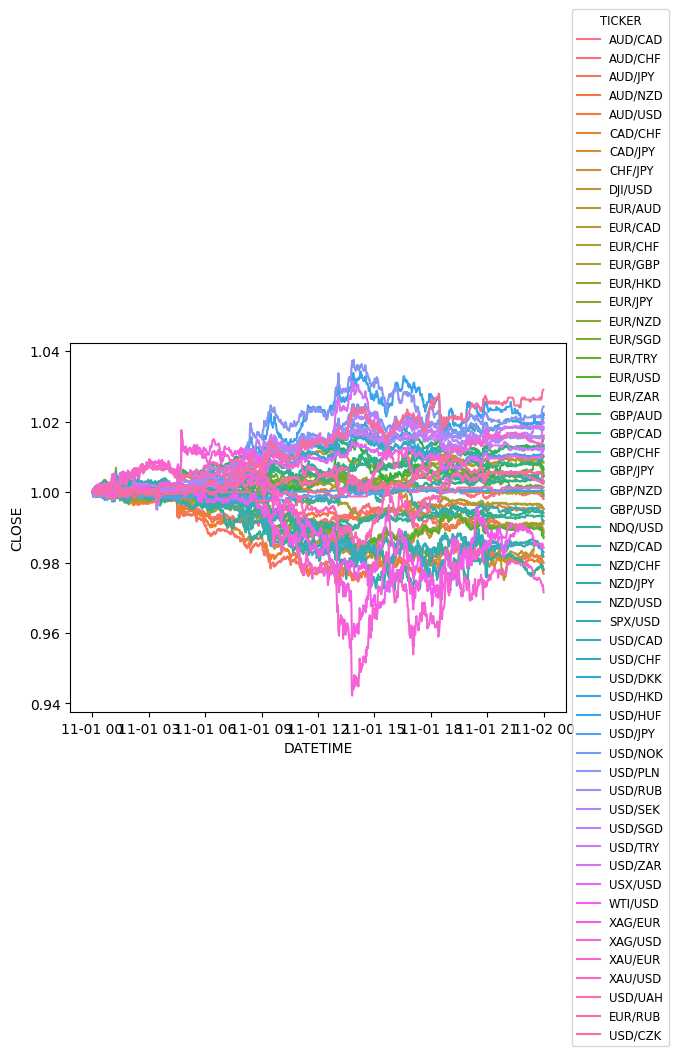

In [59]:
sns.lineplot(x="DATETIME", y="CLOSE", hue = "TICKER", data=normalized_FX)
plt.legend(
    title="TICKER",
    fontsize="small",
    title_fontsize="small",
    loc="center left",
    bbox_to_anchor=(1, 0.5)
)
plt.show()